# Resolución de la dinámica en forma simbólica

Se presenta un algoritmo simple para resolver la dinámica por Euler Lagrange
Luego se aplica a un carro-rampa y se muestra el resultado de la integración numérica para calcular la trayectoria en el espacio de operación

In [2]:
import numpy as np
import sympy as sp
from IPython.display import display, Math
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
import matplotlib
%matplotlib inline

print(matplotlib.get_backend())

import control as ct

inline


## Cinemática simbólica

Método aplicable a cualquier robot serie

In [2]:
def fkine_symbolic(DH):
    """
    Cinemática directa con parámetros DH distales.

    Parámetros:
    -----------
    DH : lista de diccionarios
        Cada elemento corresponde a {'a':..., 'd':..., 'alpha':..., 'theta':..., 'joint_type':... }.
        Los valores pueden ser constantes o simbólicos.
        joint_type : tipo de articulación ('r' o 'p').

    Retorna:
    --------
    q : vector de variables articulares simbólicas
    A_list : lista con matrices homogéneas A_i (de i-1 a i)
    W_list : lista con matrices homogéneas acumuladas (0 hasta i)
    """

    N_axis = len(DH)

    # Defino variables articulares simbólicas
    q = sp.symbols(f'q1:{N_axis+1}', real=True)

    # Construyo matrices A_i
    A_list = []
    W_list = []

    for i in range(0,N_axis):
        theta = DH[i].get('theta', sp.symbols(f"theta{i+1}", real=True))
        d     = DH[i].get('d',     sp.symbols(f"d{i+1}", real=True))
        a     = DH[i].get('a',     sp.symbols(f"a{i+1}", real=True))
        alpha = DH[i].get('alpha', sp.symbols(f"alpha{i+1}", real=True))

        # Sustituyo según tipo de articulación
        if DH[i].get('joint_type') == 'r':   # rotacional → theta = q[i]
            theta = q[i]
        elif DH[i].get('joint_type') == 'p': # prismática → d = q[i]
            d = q[i]

        A = sp.Matrix([
            [sp.cos(theta), -sp.sin(theta)*sp.cos(alpha),  sp.sin(theta)*sp.sin(alpha), a*sp.cos(theta)],
            [sp.sin(theta),  sp.cos(theta)*sp.cos(alpha), -sp.cos(theta)*sp.sin(alpha), a*sp.sin(theta)],
            [0,                      sp.sin(alpha),                      sp.cos(alpha),               d],
            [0,                      0,                                      0,                       1]
        ])
        A = sp.simplify(A)
        A = sp.nsimplify(A, tolerance=1e-12)
        A_list.append(A)

        if i == 0:
            W_list.append(A)
        else:
            W_list.append(sp.simplify(W_list[-1]*A))

    return A_list, W_list, q


In [3]:
def inv_SE3(T):
    R = T[:3, :3]
    p = T[:3, 3]

    R_T = R.T
    p_new = -R_T @ p

    T_inv = sp.eye(4)
    T_inv[:3, :3] = R_T
    T_inv[:3, 3] = p_new

    return T_inv

def calcAij(A, i, j):
        """
        Calcula la transformación entre i y j usando lista de matrices A_i.

        Parámetros:
            A : list of sympy.Matrix (A[0] = A1 en MATLAB)
            i, j : índices (base 0)
            simplify_result : bool (opcional, evitar por defecto)

        Retorna:
            Aij : sympy.Matrix
        """

        # convertir a índices Python
        i -= 1
        j -= 1

        # Determinar sentido
        if i < j:
            ss = -1
            k_idx = list(range(i, j+1))
        elif i > j:
            ss = 1
            k_idx = list(range(j, i+1))
        else:
            return sp.eye(4)

        # Producto
        Aij = sp.eye(4)

        for k in range(1, len(k_idx)):
            Aij = Aij @ A[k_idx[k]]

        # Inversión si corresponde
        if ss == -1:
            Aij = inv_SE3(Aij)

        Aij = sp.simplify(Aij)
        return Aij


def jacobian_symbolic(DH, A, oJv, pJv, pJw):
    """
    Jacobiano simbólico

    Parámetros:
        DH : parámetros cinemáticos del robot
        A : lista de matrices homogéneas (A[0] = A1)
        oJv, pJv, pJw : índices de frames (base 0)
    """

    J = sp.zeros(6, len(DH))

    for iq in range(len(DH)):

        is_revolute = (DH[iq].get('joint_type') == 'r')

        Aojv = calcAij(A, oJv, iq)
        Apjv = calcAij(A, pJv, iq)
        Apjw = calcAij(A, pJw, iq)

        # --- bloque lineal ---
        p = Aojv[:3, 3]

        for ic in range(3):
            if is_revolute:
                r = Apjv[:3, ic]
                v_aux = p.cross(r)
            else:
                v_aux = Apjw[:3, ic]

            J[ic, iq] = sp.simplify(v_aux[2])

        # --- bloque angular ---
        for ic in range(3):
            if is_revolute:
                r = Apjw[:3, ic]
                J[ic+3, iq] = sp.simplify(r[2])
            else:
                J[ic+3, iq] = 0

    return J

## Dinámica simbólica

Método aplicable a cualquier robot serie

In [4]:
def dynamics_lagrange(DH, A_list, W_list, q, g_vec,dyn_params, Kmethod='trace'):
    """
    Calcula las matrices dinámicas M, C y el vector G de un robot genérico
    usando el formalismo de Lagrange y los parámetros dinámicos.

    Parámetros:
    -----------
    DH :
    A_list:
    W_list : list of sympy.Matrix
        Lista de transformaciones homogéneas acumuladas (de la base hasta cada eslabón).
    q : list of sympy.Symbol
        Vector de coordenadas articulares.
    g_vec : sympy.Matrix
        Vector de gravedad (ej: sp.Matrix([0, -9.81, 0]) para gravedad en -y).

    Retorna:
    --------
    M : sympy.Matrix
        Matriz de inercia.
    C : sympy.Matrix
        Matriz centrífuga/coriolis.
    G : sympy.Matrix
        Vector de gravedad.
    """

    N_axis = len(q)

    # Variables simbólicas: velocidades y aceleraciones
    q_p  = sp.symbols(f'qp_1:{N_axis+1}', real=True)
    q_2p = sp.symbols(f'q2p_1:{N_axis+1}', real=True)

    # Construyo matrices de pseudoinercia
    I_list = []
    Io_list = []
    mrg_list = []
    m_list = []
    for i in range(N_axis):
        Ioxx = dyn_params[i].get('Ioxx', sp.symbols(f"Ioxx{i+1}", real=True))
        Ioyy = dyn_params[i].get('Ioyy', sp.symbols(f"Ioyy{i+1}", real=True))
        Iozz = dyn_params[i].get('Iozz', sp.symbols(f"Iozz{i+1}", real=True))
        Ioxy = dyn_params[i].get('Ioxy', sp.symbols(f"Ioxy{i+1}", real=True))
        Ioxz = dyn_params[i].get('Ioxz', sp.symbols(f"Ioxz{i+1}", real=True))
        Ioyz = dyn_params[i].get('Ioyz', sp.symbols(f"Ioyz{i+1}", real=True))
        m = dyn_params[i].get('m', sp.symbols(f"m{i+1}", real=True))
        xg = dyn_params[i].get('xg', sp.symbols(f"xg{i+1}", real=True))
        yg = dyn_params[i].get('yg', sp.symbols(f"yg{i+1}", real=True))
        zg = dyn_params[i].get('zg', sp.symbols(f"zg{i+1}", real=True))

        # Matriz de pseudoinercia
        Ii = sp.Matrix([
            [(Ioyy+Iozz-Ioxx)/2,                  -Ioxy,                    -Ioxz, m*xg],
            [             -Ioxy,     (Ioxx+Iozz-Ioyy)/2,                    -Ioyz, m*yg],
            [             -Ioxz,                  -Ioyz,       (Ioxx+Ioyy-Iozz)/2, m*zg],
            [               m*xg,                  m*yg,                      m*zg,   m]
        ])
        I_list.append(Ii)

        # Matriz de inercia
        IIi = sp.Matrix([
            [Ioxx, Ioxy, Ioxz],
            [Ioxy, Ioyy, Ioyz],
            [Ioxz, Ioyz, Iozz] ])
        Io_list.append(IIi)

        mrg = m*sp.Matrix([xg, yg, zg, 1])
        mrg_list.append(mrg)

        m_list.append(m)


    if Kmethod == 'trace':
        # --- Cálculo de M ---
        print("Calculando M según método de la traza...")
        M = sp.zeros(N_axis, N_axis)
        for i in range(N_axis):
            for j in range(N_axis):
                val = 0
                for k in range(N_axis):
                    dW1 = sp.diff(W_list[k], q[i])
                    dW2 = sp.diff(W_list[k], q[j])
                    val += sp.trace(dW1 * I_list[k] * dW2.T)
                M[i,j] = sp.simplify(val)
                #M[i,j] = sp.nsimplify(M[i,j], tolerance=1e-12)
    else:
        # --- Cálculo de M ---
        print("Calculando M según método de robótica ...")
        M = sp.zeros(N_axis, N_axis)
        for i in range(N_axis):
            Ji = jacobian_symbolic(DH, A_list, i+1, i+1, i+1)
            Jvi = Ji[0:3, 0:i+1]
            Jwi = Ji[3:6, 0:i+1]

            # padding de ceros
            if i < N_axis:
                Jvi = Jvi.row_join(sp.zeros(3, N_axis - (i+1)))
                Jwi = Jwi.row_join(sp.zeros(3, N_axis - (i+1)))

            skew_rgi = get_skew(sp.Matrix(mrg_list[i][0:3]))

            Mi = sp.simplify(
                m_list[i] * (Jvi.T * Jvi)
                + Jwi.T * Io_list[i] * Jwi
                - Jvi.T * skew_rgi * Jwi
                + Jwi.T * skew_rgi * Jvi
            )

            M += Mi

        M = sp.simplify(M)
    print('OK')

    # --- Cálculo de C ---
    print("Calculando C ...")
    C = sp.zeros(N_axis, N_axis)
    for s in range(N_axis):
        for j in range(N_axis):
            val = 0
            for k in range(N_axis):
                dW1 = sp.diff(M[s,j], q[k])
                dW2 = sp.diff(M[s,k], q[j])
                dW3 = sp.diff(M[j,k], q[s])
                h = (dW1 + dW2 - dW3)/2
                val += h * q_p[k]
            C[s,j] = sp.simplify(val)
            #C[i,j] = sp.nsimplify(C[s,j], tolerance=1e-12)

    # --- Cálculo de G ---
    print("Calculando G ...")
    G = sp.zeros(N_axis, 1)
    for s in range(N_axis):
        val = 0
        for k in range(s, N_axis):
            dW4 = sp.diff(W_list[k], q[s])
            val += -sp.Matrix.hstack(g_vec.T, sp.Matrix([1])).dot(dW4 * mrg_list[k])
        G[s] = sp.simplify(val)
        #G[s] = sp.nsimplify(G[s], tolerance=1e-12)

    return M, C, G, q_p, q_2p


def get_skew(v):
    """
    Devuelve la matriz skew-simétrica de un vector 3x1

    Parámetros:
    -----------
    v : iterable o Matrix (3,)

    Retorna:
    --------
    3x3 Matrix (skew)
    """
    v = sp.Matrix(v)

    return sp.Matrix([
        [0,     -v[2],  v[1]],
        [v[2],   0,    -v[0]],
        [-v[1],  v[0],  0]
    ])


# Carro-Rampa


In [5]:
# Definición de los parámetros cinemáticos y dinámicos del robot
# Los que quiero dejar como parámetro, no deben tener especificado valor
DH_params = {
    0: {'theta':np.pi/2, 'alpha': np.pi/2, 'a':0 ,'d':0, 'joint_type':'r'},
    1: {'theta':0 ,'alpha': 0, 'd':0, 'joint_type':'p'}
}

dyn_params  = {
    0:{'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'xg': 0, 'yg': 0, 'zg': 0},
    1:{'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'xg': 0, 'yg': 0, 'zg': 0}
}

# Montaje
g_vec = sp.Matrix([0, -9.81, 0])


# Cálculo de la cinemática directa simbólica
print("Calculando cinemática directa ...")
A_list, W_list, q = fkine_symbolic(DH_params)
print("POSE(q)=")
sp.pretty_print(W_list[-1])
print("Variables articulares:", q)

# Cálculo de las matrices de la dinámica
print("Calculando las matrices de la dinámica ...")
M, C, G, q_p, q_2p = dynamics_lagrange(DH_params, A_list, W_list, q, g_vec, dyn_params,Kmethod='robotics')


print("Matriz M:")
sp.pprint(M)
print("\nMatriz C:")
sp.pprint(C)
print("\nVector G:")
sp.pprint(G)



Calculando cinemática directa ...
POSE(q)=
⎡cos(q₁)  0  sin(q₁)   a₂⋅cos(q₁) + q₂⋅sin(q₁)⎤
⎢                                             ⎥
⎢sin(q₁)  0  -cos(q₁)  a₂⋅sin(q₁) - q₂⋅cos(q₁)⎥
⎢                                             ⎥
⎢   0     1     0                 0           ⎥
⎢                                             ⎥
⎣   0     0     0                 1           ⎦
Variables articulares: (q1, q2)
Calculando las matrices de la dinámica ...
Calculando M según método de robótica ...
OK
Calculando C ...
Calculando G ...
Matriz M:
⎡                   ⎛  2     2⎞        ⎤
⎢Ioyy₁ + Ioyy₂ + m₂⋅⎝a₂  + q₂ ⎠  -a₂⋅m₂⎥
⎢                                      ⎥
⎣            -a₂⋅m₂                m₂  ⎦

Matriz C:
⎡m₂⋅q₂⋅qp₂   m₂⋅q₂⋅qp₁⎤
⎢                     ⎥
⎣-m₂⋅q₂⋅qp₁      0    ⎦

Vector G:
⎡9.81⋅m₂⋅(a₂⋅cos(q₁) + q₂⋅sin(q₁))⎤
⎢                                 ⎥
⎣        -9.81⋅m₂⋅cos(q₁)         ⎦


## Modelado considerando actuar con $\ddot{q}_1$

In [6]:
# Resolución para el segundo eslabón, pensando que está libre (péndulo subactuado)
tau2 = (M[1,:]*sp.Matrix(q_2p))[0] + (C[1,:]*sp.Matrix(q_p))[0] + G[1]
#display(Math(sp.latex(tau2)))

sol = sp.solve(tau2, q_2p[1])
#print("Modelo no lineal de la dinámica del segundo eslabón:\n\n",sol)

print("\n\nModelo no lineal de la dinámica del segundo eslabón:\n\n")
latex_fml = sp.latex(
        sol,
        symbol_names={
            q_p[0]: r'\dot{q}_1',
            q_2p[0]: r'\ddot{q}_1',
            q_p[1]: r'\dot{q}_2',
            q_2p[1]: r'\ddot{q}_2',
        }
    )
display(Math(latex_fml))





Modelo no lineal de la dinámica del segundo eslabón:




<IPython.core.display.Math object>

### Modelo numérico

In [7]:

#  Preparo un modelo numérico para simulación
symbols = {
    str(s): s
    for s in sol[0].free_symbols
}

print(symbols)
# Reemplazamos los símbolos por sus valores numéricos
parametros = {
    symbols['a2']: 0.05,
}

sol_num = sol[0].subs(parametros)
print(sol_num)
ddq2 = sp.lambdify((q[0], q[1], q_p[0], q_2p[0]),sol_num)

# El estado es la posición y velocidad del eslabon 2
# Pero agrego la velocidad del 1 porque entro con aceleracion angular 1 y necesito integrar
def dxdt(t, x, u):
    q1, q2, qp_1, qp_2 = x
    q2p_1 = u(t, x)

    return [
        qp_1,
        qp_2,
        q2p_1,
        ddq2(q1, q2, qp_1, q2p_1),
    ]



{'a2': a2, 'q2': q2, 'qp_1': qp_1, 'q1': q1, 'q2p_1': q2p_1}
q2*qp_1**2 + 0.05*q2p_1 + 9.81*cos(q1)


### Simulación

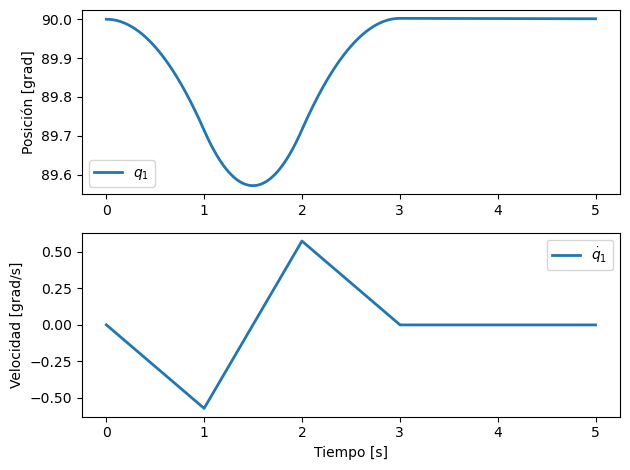

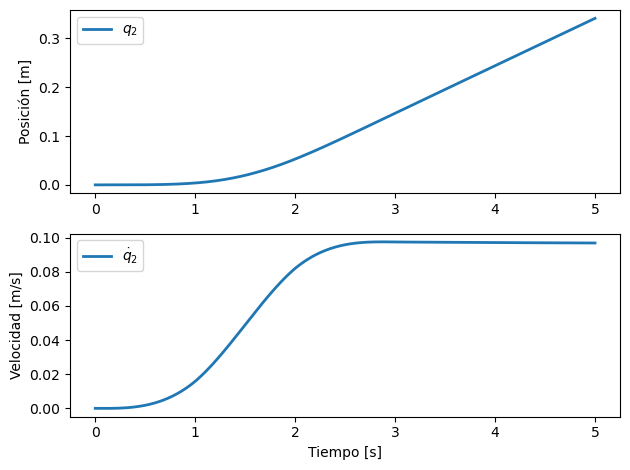

In [8]:
# Parámetros de la simulación
Ts = 0.001
# Estado inicial del péndulo
x0 = np.r_[np.pi/2,0,0,0]
t_span = [0, 5]
# Armo la base de tiempo para las muestras
t = np.arange(t_span[0], t_span[1]+Ts, Ts)

# Ejemplo: torques nulos
def u_func(t, x):
    if t<1:
        acel=-0.01
    elif t<2:
        acel=0.02
    elif t<3:
        acel=-0.01
    else:
        acel=0
    return acel

ode_sol = solve_ivp(dxdt, t_span, x0, args=(u_func,), max_step=0.01, t_eval=t)

# Eje 1
plt.figure()
plt.subplot(2,1,1)
plt.plot(ode_sol.t,ode_sol.y[0,:].T*180/np.pi,lw=2)
plt.legend(['$q_1$'])
plt.ylabel('Posición [grad]')
plt.subplot(2,1,2)
plt.plot(ode_sol.t,ode_sol.y[2,:].T*180/np.pi,lw=2)
plt.legend([r'$\dot{q}_1$'])
plt.ylabel('Velocidad [grad/s]')
plt.xlabel('Tiempo [s]')
plt.tight_layout()

# Eje 2
plt.figure()
plt.subplot(2,1,1)
plt.plot(ode_sol.t,ode_sol.y[1,:].T,lw=2)
plt.legend(['$q_2$'])
plt.ylabel('Posición [m]')
plt.subplot(2,1,2)
plt.plot(ode_sol.t,ode_sol.y[3,:].T,lw=2)
plt.legend([r"$\dot{q}_2$"])
plt.ylabel('Velocidad [m/s]')
plt.xlabel('Tiempo [s]')
plt.tight_layout()


## Modelado actuando con $\tau_1$

In [9]:
# Resolución para el segundo eslabón, pensando que está libre (péndulo subactuado)
tau  = sp.symbols(f'tau_1:{len(q)+1}', real=True)
sol = M.inv() *(sp.Matrix([tau[0],0])- C * sp.Matrix(q_p) - G)

print("\n\nModelo no lineal de la dinámica:\n\n")
latex_fml = sp.latex(
        sol,
        symbol_names={
            q_p[0]: r'\dot{q}_1',
            q_2p[0]: r'\ddot{q}_1',
            q_p[1]: r'\dot{q}_2',
            q_2p[1]: r'\ddot{q}_2',
        }
    )
display(Math(latex_fml))





Modelo no lineal de la dinámica:




<IPython.core.display.Math object>

In [10]:
ae = 0.2    # Largo del eslabon 1
be = 0.02   # Sección del eslabón 1
masa1 = 0.5
masa2 = 0.5
Ig1xx = masa1*(be**2)/6
Ig1yy = masa1*(ae**2+be**2)/12
Ig1zz = masa1*(ae**2+be**2)/12
yg2 = 0.1


#  Preparo un modelo numérico para simulación
symbols = {
    str(s): s
    for s in sol[0].free_symbols
}

# Reemplazamos los símbolos por sus valores numéricos
parametros = {
    symbols['a2']: 0.05,
    symbols['m2']: masa2,
    symbols['Ioyy1']: Ig1yy,
    symbols['Ioyy2']: Ig1yy/10,
}

sol_num = sol.subs(parametros)
print(sol_num)

ddq = sp.lambdify(
    (q[0], q[1], q_p[0], q_p[1], tau[0]),
    sol_num,
    'numpy'
)

# Defino el wrapper de la función de la evolución del estado
def dxdt(t, x, u):
    q_1, q_2, qp_1, qp_2 = x
    tau_1 = u(t, x)
    q2p_1, q2p_2 = ddq(q_1, q_2, qp_1, qp_2, tau_1)
    return [
        qp_1,
        qp_2,
        q2p_1.item(),
        q2p_2.item()
    ]


Matrix([[0.05*(0.5*q2*qp_1**2 + 4.905*cos(q1))/(0.5*q2**2 + 0.00185166666666667) + (-1.0*q2*qp_1*qp_2 - 4.905*q2*sin(q1) + tau_1 - 0.24525*cos(q1))/(0.5*q2**2 + 0.00185166666666667)], [0.05*(-1.0*q2*qp_1*qp_2 - 4.905*q2*sin(q1) + tau_1 - 0.24525*cos(q1))/(0.5*q2**2 + 0.00185166666666667) + (0.5*q2**2 + 0.00310166666666667)*(0.5*q2*qp_1**2 + 4.905*cos(q1))/(0.25*q2**2 + 0.000925833333333333)]])


### Diseño del control

Así como está a lazo abierto, se cae solo por viento numérico.
Cierro el lazo reubicando polos sin considerar la cascada que se tiene por el servo


In [11]:
# Vamos a linealizar antes de continuar
x = sp.Matrix([
    q[0],
    q[1],
    q_p[0],
    q_p[1]
])

f = sp.Matrix([
    q_p[0],
    q_p[1],
    sol_num[0],
    sol_num[1]
])

A = f.jacobian(x)
B = f.jacobian([tau[0]])


# Queremos la rampa en el origen y el carrito en el medio
x_eq = {
    q[0]: np.pi/2,
    q[1]: 0,
    q_p[0]: 0,
    q_p[1]: 0
}

u_eq = {
    tau[0]: 0
}

A_eq = A.subs(x_eq).subs(u_eq)
B_eq = B.subs(x_eq).subs(u_eq)

print("A_eq=\n",A_eq)
print("B_eq=\n",B_eq)

A_num = np.array(A_eq).astype(float)
B_num = np.array(B_eq).astype(float)
eig = np.linalg.eigvals(A_num)
print("Autovalores del sistema linealizado", eig)

sistema = ct.ss(A_num, B_num, np.eye(4), np.zeros((4,1)))

print("Rango de controlabilidad:", np.linalg.matrix_rank(ct.ctrb(A_num, B_num)))

# Propongo la ubicación de los polos
polos = [-2, -3, -4, -5]
K = ct.acker(A_num, B_num, polos)
print("K =", K)



A_eq=
 Matrix([[0, 0, 1, 0], [0, 0, 0, 1], [0, -2648.96489648965, 0, 0], [-9.81000000000000, -132.448244824482, 0, 0]])
B_eq=
 Matrix([[0], [0], [540.054005400540], [27.0027002700270]])
Autovalores del sistema linealizado [ 2.04988410e-15+15.50805303j  2.04988410e-15-15.50805303j
 -1.03947806e+01 +0.j          1.03947806e+01 +0.j        ]
Rango de controlabilidad: 4
K = [ 0.13260085 -4.92765036  0.02737673 -0.02906796]


### Simulación

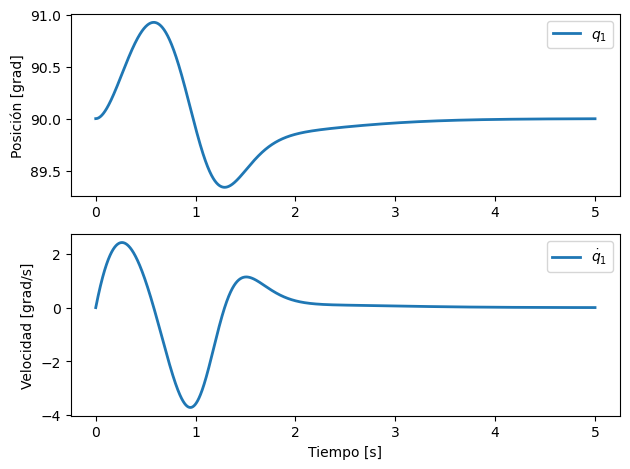

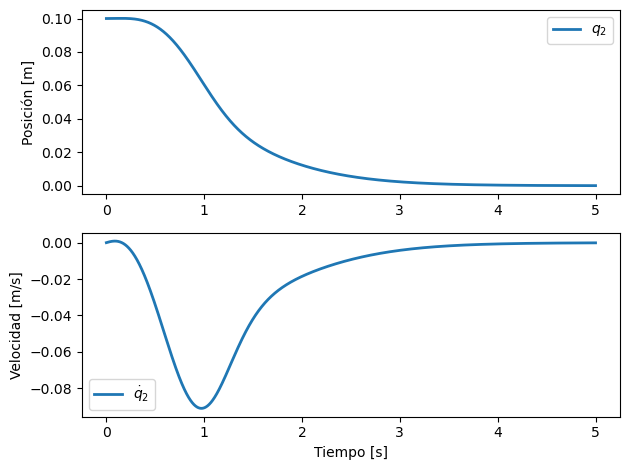

In [12]:
# Parámetros de la simulación
Ts = 0.001
# Estado inicial del péndulo
x0 = np.r_[np.pi/2,0.1,0,0]
xe = np.r_[np.pi/2,0,0,0]
t_span = [0, 5]
# Armo la base de tiempo para las muestras
t = np.arange(t_span[0], t_span[1]+Ts, Ts)

def u_func(t, x):
    return -K @ (x - xe)

ode_sol = solve_ivp(dxdt, t_span, x0, args=(u_func,), max_step=0.01, t_eval=t)

# Eje 1
plt.figure()
plt.subplot(2,1,1)
plt.plot(ode_sol.t,ode_sol.y[0,:].T*180/np.pi,lw=2)
plt.legend(['$q_1$'])
plt.ylabel('Posición [grad]')
plt.subplot(2,1,2)
plt.plot(ode_sol.t,ode_sol.y[2,:].T*180/np.pi,lw=2)
plt.legend([r'$\dot{q}_1$'])
plt.ylabel('Velocidad [grad/s]')
plt.xlabel('Tiempo [s]')
plt.tight_layout()

# Eje 2
plt.figure()
plt.subplot(2,1,1)
plt.plot(ode_sol.t,ode_sol.y[1,:].T,lw=2)
plt.legend(['$q_2$'])
plt.ylabel('Posición [m]')
plt.subplot(2,1,2)
plt.plot(ode_sol.t,ode_sol.y[3,:].T,lw=2)
plt.legend([r"$\dot{q}_2$"])
plt.ylabel('Velocidad [m/s]')
plt.xlabel('Tiempo [s]')
plt.tight_layout()


## Control en cascada

In [13]:
# Parámetros del servo interno
Kps = 100
Kds = 1


# Entrada externa: referencia angular del servo
q1_ref = sp.Symbol('q1_ref')

# Modelo del servo (supongo):
# tau1 = Kps*(q1_ref - q1) - Kds*qp1
tau_servo = Kps*(q1_ref - q[0]) - Kds*q_p[0]

# Dinámica mecánica con el servo incluido
ddq_servo = sol_num.subs(tau[0], tau_servo)

# Lambda de las aceleraciones
ddq_servo_fun = sp.lambdify(
    (q[0], q[1], q_p[0], q_p[1], q1_ref),
    ddq_servo,
    'numpy'
)

def dxdt_servo(t, x, u_ext):
    q_1, q_2, qp_1, qp_2 = x

    # Entrada externa: referencia del servo
    q1_ref = u_ext(t, x)

    # Dinámica mecánica + servo
    ddq_1, ddq_2 = ddq_servo_fun(
        q_1, q_2, qp_1, qp_2, q1_ref
    )

    return [
        qp_1,
        qp_2,
        np.asarray(ddq_1).item(),
        np.asarray(ddq_2).item()
    ]




### Diseño del control externo

In [14]:

# Estados
x = sp.Matrix([
    q[0],
    q[1],
    q_p[0],
    q_p[1]
])

# Sistema completo en espacio de estados
f_servo = sp.Matrix([
    q_p[0],
    q_p[1],
    ddq_servo[0],
    ddq_servo[1]
])

# Matrices de la planta completa con servo interno
A_servo = f_servo.jacobian(x)
B_servo = f_servo.jacobian([q1_ref])

# Punto de equilibrio
xe = {
    q[0]: np.pi/2,
    q[1]: 0,
    q_p[0]: 0,
    q_p[1]: 0,
    q1_ref: np.pi/2
}

A_servo_eq = A_servo.subs(xe)
B_servo_eq = B_servo.subs(xe)

A_servo_num = np.array(A_servo_eq).astype(float)
B_servo_num = np.array(B_servo_eq).astype(float)

print("A =\n", A_servo_num)
print("B =\n", B_servo_num)
print("Polos =", np.linalg.eigvals(A_servo_num))

print("Rango de controlabilidad:", np.linalg.matrix_rank(ct.ctrb(A_servo_num, B_servo_num)))
sistema = ct.ss(A_servo_num, B_servo_num, np.eye(4), np.zeros((4,1)))

# Propongo la ubicación de los polos
polos = [-2, -3, -4, -5]
K = ct.acker(A_servo_num, B_servo_num, polos)
print("K =", K)


A =
 [[ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [-5.40054005e+04 -2.64896490e+03 -5.40054005e+02  0.00000000e+00]
 [-2.71008003e+03 -1.32448245e+02 -2.70027003e+01  0.00000000e+00]]
B =
 [[    0.        ]
 [    0.        ]
 [54005.40054005]
 [ 2700.270027  ]]
Polos = [-407.05579615 -132.99342063    0.690446     -0.69523462]
Rango de controlabilidad: 4
K = [-9.98673991e-01 -4.92765036e-02 -9.72623269e-03 -2.90679579e-04]


### Simulación

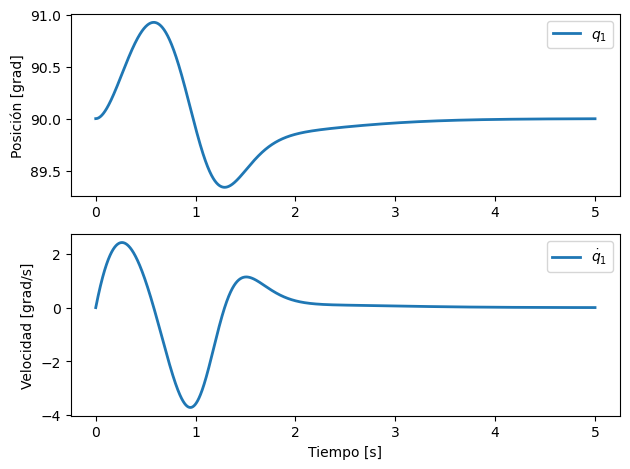

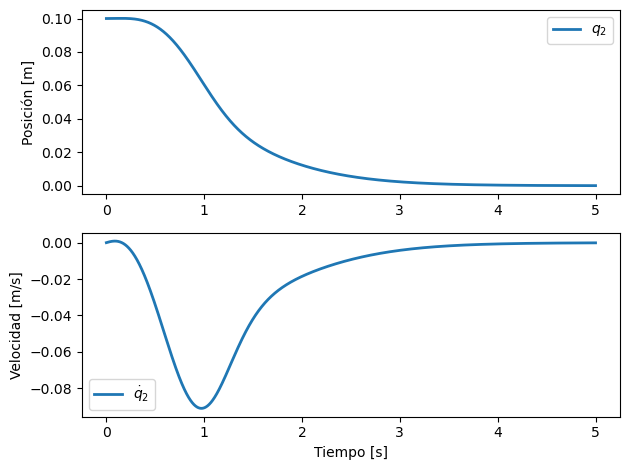

In [15]:
# Parámetros de la simulación
Ts = 0.001
# Estado inicial del péndulo
x0 = np.r_[np.pi/2,0.1,0,0]
xe = np.r_[np.pi/2,0.0,0,0]
t_span = [0, 5]
# Armo la base de tiempo para las muestras
t = np.arange(t_span[0], t_span[1]+Ts, Ts)

def u_func(t, x):
    return  np.pi/2 -K @ (x - xe)

ode_sol = solve_ivp(dxdt_servo, t_span, x0, args=(u_func,), max_step=0.01, t_eval=t)

# Eje 1
plt.figure()
plt.subplot(2,1,1)
plt.plot(ode_sol.t,ode_sol.y[0,:].T*180/np.pi,lw=2)
plt.legend(['$q_1$'])
plt.ylabel('Posición [grad]')
plt.subplot(2,1,2)
plt.plot(ode_sol.t,ode_sol.y[2,:].T*180/np.pi,lw=2)
plt.legend([r'$\dot{q}_1$'])
plt.ylabel('Velocidad [grad/s]')
plt.xlabel('Tiempo [s]')
plt.tight_layout()

# Eje 2
plt.figure()
plt.subplot(2,1,1)
plt.plot(ode_sol.t,ode_sol.y[1,:].T,lw=2)
plt.legend(['$q_2$'])
plt.ylabel('Posición [m]')
plt.subplot(2,1,2)
plt.plot(ode_sol.t,ode_sol.y[3,:].T,lw=2)
plt.legend([r"$\dot{q}_2$"])
plt.ylabel('Velocidad [m/s]')
plt.xlabel('Tiempo [s]')
plt.tight_layout()


# Ángulo de la barra con sistema biela-manivela

![cart-beam.png](cart-beam.png)

In [3]:
def angulo_barra(phi, r1, r2, l, x0, y0, rama=+1):
    """
    Calcula el ángulo de la barra (theta) en función del ángulo del servo (phi).

    Parámetros
    ----------
    phi   : ángulo del servo medido desde la horizontal [rad] (float o array)
    r1    : radio de la manivela (excentricidad sobre el eje del servo)
    r2    : distancia del pivote de la barra a la articulación con la biela
    l     : largo de la biela
    x0,y0 : posición del eje del servo respecto al pivote de la barra,
            ubicado en (x0, y0)
    rama  : +1 o -1, según la configuración de montaje del mecanismo

    Devuelve
    --------
    theta : ángulo de la barra [rad], mismo tipo/forma que phi
            (np.nan donde el mecanismo no puede cerrar el lazo)
    """
    phi = np.asarray(phi, dtype=float)

    # Posición del pin de la manivela (extremo de la biela sobre el servo)
    P2x = x0 + r1*np.cos(phi)
    P2y = -y0 + r1*np.sin(phi)

    D = np.hypot(P2x, P2y)          # distancia O1-P2

    # Condición de existencia (desigualdad triangular)
    cos_arg = (r2**2 + D**2 - l**2) / (2*r2*D)
    valido = np.abs(cos_arg) <= 1

    alpha = np.arctan2(P2y, P2x)                 # dirección O1-P2
    beta  = np.arccos(np.clip(cos_arg, -1, 1))    # ángulo interno en O1

    theta = alpha + rama*beta
    theta = np.where(valido, theta, np.nan)

    return theta if theta.shape else float(theta)

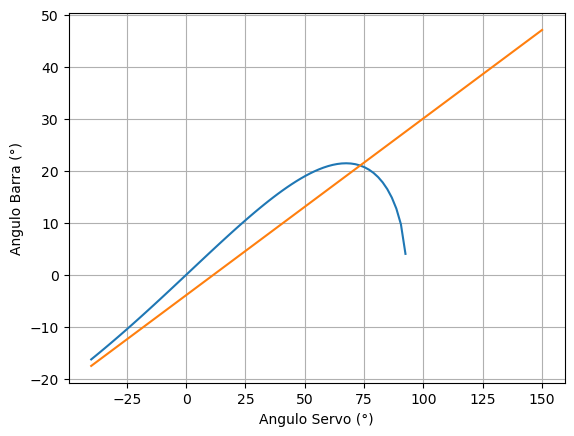

In [4]:
delta_theta = np.radians(14.07-10.8)

r1, r2, l = 45, 105, 47
x0, y0 = 60, 41 

phi = np.linspace(np.radians(-40), np.radians(150), 100)
theta = angulo_barra(phi, r1, r2, l, x0, y0, rama=1)

plt.plot(np.degrees(phi),np.degrees(theta-delta_theta),label='teorico')
plt.plot(np.degrees(phi),np.degrees(phi)*0.34-3.9,label='aproximado')
plt.xlabel('Angulo Servo (°)')
plt.ylabel('Angulo Barra (°)')
plt.grid()

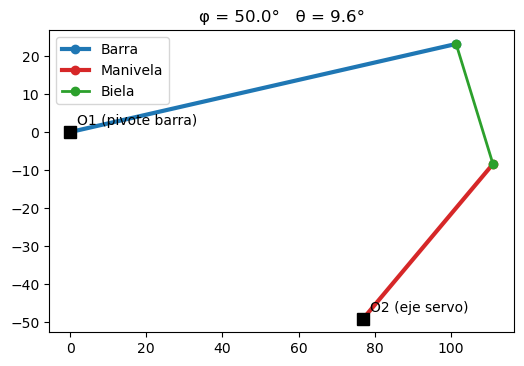

In [18]:
def graficar_mecanismo(phi, r1, r2, l, x0, y0, rama=+1, ax=None):
    """
    Dibuja el mecanismo biela-manivela-barra para un ángulo de servo phi dado.
    """
    # Posiciones clave
    O1 = np.array([0, 0])
    O2 = np.array([x0, -y0])

    P2 = O2 + r1*np.array([np.cos(phi), np.sin(phi)])   # pin de la manivela

    theta = angulo_barra(phi, r1, r2, l, x0, y0, rama=rama)
    if np.isnan(theta):
        print(f"Mecanismo no puede cerrar el lazo para phi = {np.degrees(phi):.1f}°")
        return

    P1 = O1 + r2*np.array([np.cos(theta), np.sin(theta)])  # pin sobre la barra

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    # Barra (O1 -> P1)
    ax.plot([O1[0], P1[0]], [O1[1], P1[1]], 'o-', color='tab:blue', lw=3, label='Barra')
    # Manivela (O2 -> P2)
    ax.plot([O2[0], P2[0]], [O2[1], P2[1]], 'o-', color='tab:red', lw=3, label='Manivela')
    # Biela (P1 -> P2)
    ax.plot([P1[0], P2[0]], [P1[1], P2[1]], 'o-', color='tab:green', lw=2, label='Biela')

    # Pivotes fijos
    ax.plot(*O1, 's', color='black', markersize=8)
    ax.plot(*O2, 's', color='black', markersize=8)
    ax.annotate('O1 (pivote barra)', O1, textcoords="offset points", xytext=(5,5))
    ax.annotate('O2 (eje servo)', O2, textcoords="offset points", xytext=(5,5))

    ax.set_aspect('equal')
    ax.legend()
    ax.set_title(f"φ = {np.degrees(phi):.1f}°   θ = {np.degrees(theta-delta_theta):.1f}°")

    return ax

fig, ax = plt.subplots(figsize=(6,6))
graficar_mecanismo(np.radians(50), r1, r2, l, x0, y0, rama=+1, ax=ax)
plt.show()